# Tobroco Data Mining Project

## Project Context

This notebook presents a comprehensive data understanding analysis of **6.5 million time registration records** spanning **10,286 production orders** across **183 assembly zones**. The analysis reveals **critical data quality challenges** at step-level whilst confirming that **zone-level aggregation provides a more robust foundation** for predictive modelling.

**Key Finding**: **79% of all step-level records are under 5 seconds**, indicating widespread "click-through" behaviour where operators rapidly advance through assembly steps without accurate time recording.

In [7]:
# Import libraries
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import sklearn
warnings.filterwarnings('ignore')

## 1. Data connection

In [8]:
# Database connection string
conn_str = (
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=tobroco-ai-db.database.windows.net;"
    "Database=thingworx_data;"
    "UID=sqladmin;"
    "PWD=>Qy:NhMV[F1DX2h'!%;"
)

# Establish connection
conn = pyodbc.connect(conn_str)
print("✅ Connected to Azure SQL Database")

✅ Connected to Azure SQL Database


In [10]:
query = """
WITH tr AS (
    SELECT
        t.productionordernumber,
        COUNT(DISTINCT t.assemblystepid) AS amountOfSteps,
        SUM(DATEDIFF_BIG(second, t.startdate, t.enddate)) AS durationInSeconds
    FROM ninea_timeregistrations t
    WHERE t.assemblystepid IS NOT NULL
      AND t.startdate <> t.enddate
      AND t.productionordernumber IS NOT NULL
    GROUP BY t.productionordernumber
    HAVING SUM(DATEDIFF_BIG(second, t.startdate, t.enddate)) < 1209600 --filter 'bad' measurements
       AND SUM(DATEDIFF_BIG(second, t.startdate, t.enddate)) > 60
),
po_agg AS (
    SELECT
        po.productionordernumber,
        MIN(po.dossierdescription) AS machineName,
        COUNT(*) AS amountOfOperations,
        COUNT(DISTINCT po.zoneuid) AS amountOfZones,
        COUNT(DISTINCT a.articlenumber) AS amountOfOptions
    FROM ninea_productionoperation po
    JOIN ninea_assemblystep a ON a.assemblystepid = po.assemblystepid
    WHERE po.productionordernumber IS NOT NULL
      AND po.dossierdescription IS NOT NULL
      AND po.dossierdescription <> ''
      AND po.assemblystepid IS NOT NULL
    GROUP BY po.productionordernumber
)

SELECT po_agg.productionordernumber AS productionOrderNumber,
    po_agg.machineName,
    po_agg.amountOfOperations,
    po_agg.amountOfZones,
    tr.amountOfSteps,
    po_agg.amountOfOptions,
    tr.durationInSeconds / 3600.0 AS durationInHours
FROM po_agg
JOIN tr ON tr.productionordernumber = po_agg.productionordernumber
"""

df = pd.read_sql(query, conn)
df.head()

,productionOrderNumber,machineName,amountOfOperations,amountOfZones,amountOfSteps,amountOfOptions,durationInHours
0,PO00242569,Giant G1500 X-tra,210,27,184,11,4.649166
1,PO00242571,Giant G1500 X-tra,786,73,700,39,37.434444
2,PO00242576,Giant G1500,848,73,788,39,47.318611
3,PO00242577,Giant G1500 X-tra,765,77,684,31,34.134444
4,PO00291884,Giant G2500 X-tra HD,6,1,5,3,0.599166


In [11]:
#Delete outliers

Q1 = df["durationInHours"].quantile(0.25)
Q3 = df["durationInHours"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_filtered = df[
    (df["durationInHours"] >= lower) &
    (df["durationInHours"] <= upper)
]

In [12]:
rows_before = len(df)
rows_after = len(df_filtered)
rows_skipped = rows_before - rows_after
skipped_pct = rows_skipped / rows_before * 100

print(f"Rows before: {rows_before}")
print(f"Rows after: {rows_after}")
print(f"Rows skipped: {rows_skipped}")
print(f"Skipped percentage: {skipped_pct:.2f}%")

Rows before: 3598
Rows after: 2805
Rows skipped: 793
Skipped percentage: 22.04%


## 2. Modeling

In [ ]:
from sklearn.model_selection import train_test_split

In [14]:
df_filtered.columns.tolist()

['productionOrderNumber',
 'machineName',
 'amountOfOperations',
 'amountOfZones',
 'amountOfSteps',
 'amountOfOptions',
 'durationInHours']

In [15]:
#Split features and label
X = df_filtered.drop(columns=["durationInHours", "productionOrderNumber", "machineName"])
y = df_filtered["durationInHours"]

In [18]:
#Split train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Models
models = [
    ("Linear Regression", Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])),
    
    ("Ridge Regression", Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42))
    ])),
    
    ("ElasticNet", Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42))
    ])),
    
    ("Neural Network", Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
    ])),
    
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    
    ("Gradient Boosting", XGBRegressor(
        n_estimators=100,
        random_state=42,
        verbosity=0
    )),
    
    ("CatBoost", CatBoostRegressor(
        iterations=100,
        learning_rate=0.1,
        verbose=0,
        random_state=42
    )),
]

# 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Scoring metrics
scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "r2": "r2"
}

results = []

for name, estimator in models:
    print(f"\nCross-validating {name}...")
    
    cv_results = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    mae_scores = -cv_results["test_mae"]
    mse_scores = -cv_results["test_mse"]
    rmse_scores = np.sqrt(mse_scores)
    r2_scores = cv_results["test_r2"]
    
    results.append({
        "model": name,
        "CV_MAE_mean": mae_scores.mean(),
        "CV_MAE_std": mae_scores.std(),
        "CV_MSE_mean": mse_scores.mean(),
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_R2_mean": r2_scores.mean(),
        "CV_R2_std": r2_scores.std()
    })

results_df = pd.DataFrame(results).sort_values("CV_R2_mean", ascending=False)
print(results_df)


Cross-validating Linear Regression...

Cross-validating Ridge Regression...

Cross-validating ElasticNet...

Cross-validating Neural Network...

Cross-validating Random Forest...

Cross-validating Gradient Boosting...

Cross-validating CatBoost...
               model  CV_MAE_mean  CV_MAE_std  CV_MSE_mean  CV_RMSE_mean  \
3     Neural Network     4.396423    0.189781    39.326979      6.252471   
6           CatBoost     4.346225    0.197902    39.654779      6.268557   
4      Random Forest     4.289859    0.153852    41.026940      6.375151   
5  Gradient Boosting     4.457167    0.132361    43.465063      6.571808   
1   Ridge Regression     6.468612    0.395931    72.374627      8.492789   
0  Linear Regression     6.468604    0.395397    72.375182      8.492856   
2         ElasticNet     7.342083    0.448309    96.118041      9.782978   

   CV_R2_mean  CV_R2_std  
3    0.774064   0.027867  
6    0.772576   0.035127  
4    0.764789   0.036719  
5    0.750199   0.032636  
1    0.

In [25]:
model_dict = {name: estimator for name, estimator in models}

best_model_name = results_df.iloc[0]["model"]
best_model = model_dict[best_model_name]

print(f"Best CV model: {best_model_name}")

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nFinal test performance:")
print(f"{best_model_name} - MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")


Best CV model: Neural Network

Final test performance:
Neural Network - MAE: 4.5612, MSE: 39.0423, RMSE: 6.2484, R2: 0.7836


## Model performance comparison
Visualize the key model evaluation metrics to compare predictive quality across all trained models.

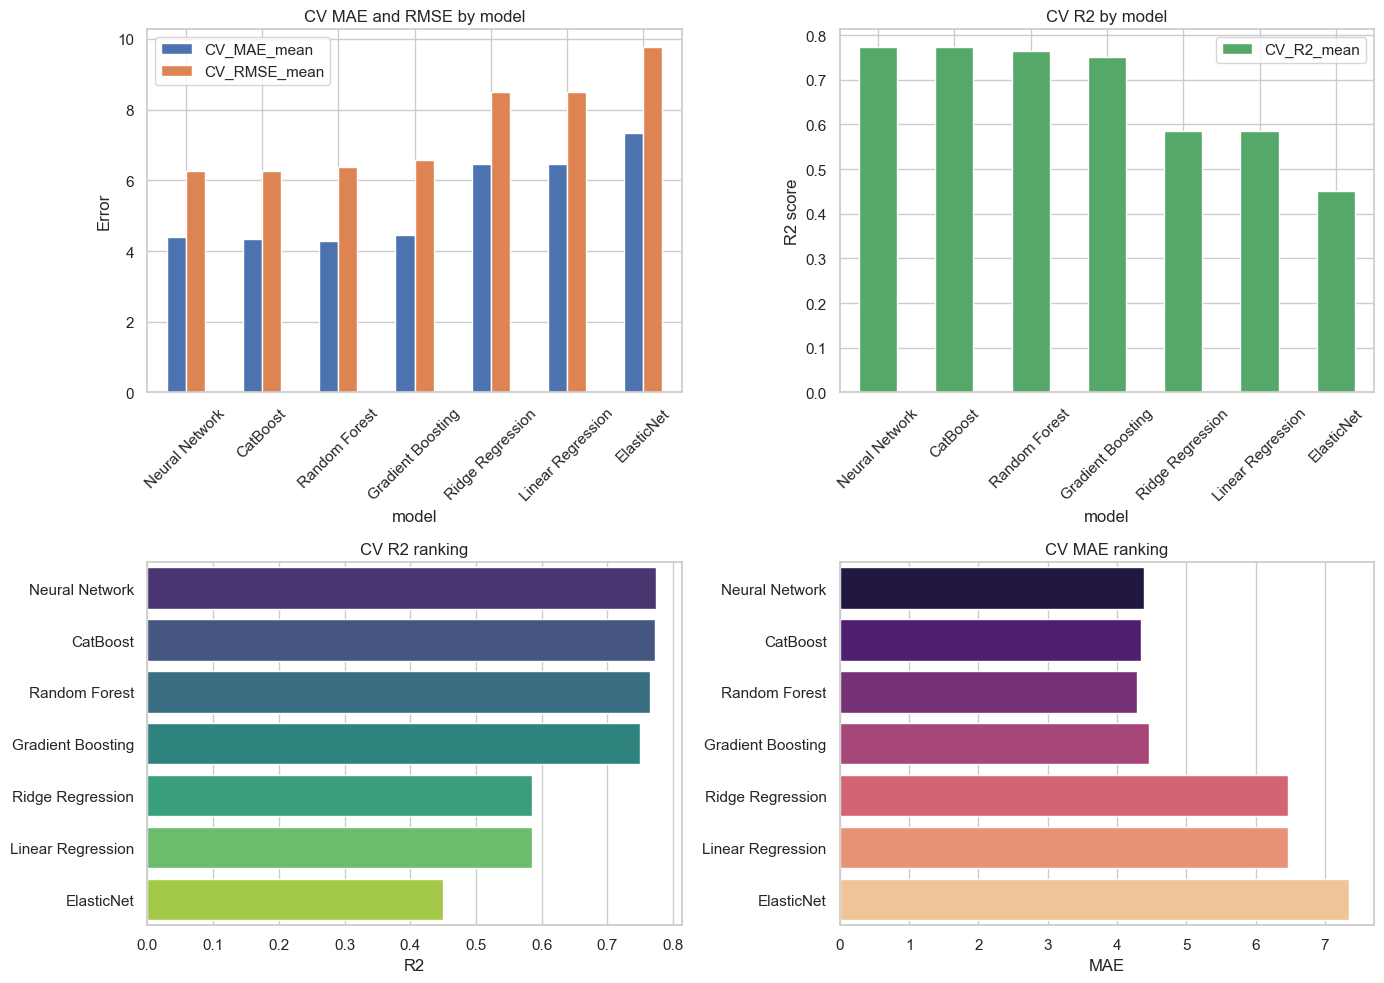

In [27]:
sns.set_theme(style="whitegrid")

metrics_df = results_df.set_index("model")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Errors
metrics_df[["CV_MAE_mean", "CV_RMSE_mean"]].plot.bar(ax=axes[0, 0], rot=45)
axes[0, 0].set_title("CV MAE and RMSE by model")
axes[0, 0].set_ylabel("Error")

# R2
metrics_df[["CV_R2_mean"]].plot.bar(ax=axes[0, 1], color=["C2"], rot=45)
axes[0, 1].set_title("CV R2 by model")
axes[0, 1].set_ylabel("R2 score")

# R2 ranking
sns.barplot(x="CV_R2_mean", y="model", data=results_df, palette="viridis", ax=axes[1, 0])
axes[1, 0].set_title("CV R2 ranking")
axes[1, 0].set_xlabel("R2")
axes[1, 0].set_ylabel("")

# MAE ranking
sns.barplot(x="CV_MAE_mean", y="model", data=results_df, palette="magma", ax=axes[1, 1])
axes[1, 1].set_title("CV MAE ranking")
axes[1, 1].set_xlabel("MAE")
axes[1, 1].set_ylabel("")

fig.tight_layout()
plt.show()
